In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/yeanzc/telco-customer-churn-ibm-dataset/Telco_customer_churn.xlsx


In [2]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Telco_customer_churn.xlsx"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "yeanzc/telco-customer-churn-ibm-dataset",
  file_path,
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_16/1506678080.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


First 5 records:    CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month   

  Paperless Billing             Payment Method  Mon

**Data Exploration(EDA)**


In [3]:
df.shape

(7043, 33)

In [4]:
df.isna

<bound method DataFrame.isna of       CustomerID  Count        Country       State          City  Zip Code  \
0     3668-QPYBK      1  United States  California   Los Angeles     90003   
1     9237-HQITU      1  United States  California   Los Angeles     90005   
2     9305-CDSKC      1  United States  California   Los Angeles     90006   
3     7892-POOKP      1  United States  California   Los Angeles     90010   
4     0280-XJGEX      1  United States  California   Los Angeles     90015   
...          ...    ...            ...         ...           ...       ...   
7038  2569-WGERO      1  United States  California       Landers     92285   
7039  6840-RESVB      1  United States  California      Adelanto     92301   
7040  2234-XADUH      1  United States  California         Amboy     92304   
7041  4801-JZAZL      1  United States  California  Angelus Oaks     92305   
7042  3186-AJIEK      1  United States  California  Apple Valley     92308   

                    Lat Long   

In [5]:
# Quick structural and data type summary
df.info

<bound method DataFrame.info of       CustomerID  Count        Country       State          City  Zip Code  \
0     3668-QPYBK      1  United States  California   Los Angeles     90003   
1     9237-HQITU      1  United States  California   Los Angeles     90005   
2     9305-CDSKC      1  United States  California   Los Angeles     90006   
3     7892-POOKP      1  United States  California   Los Angeles     90010   
4     0280-XJGEX      1  United States  California   Los Angeles     90015   
...          ...    ...            ...         ...           ...       ...   
7038  2569-WGERO      1  United States  California       Landers     92285   
7039  6840-RESVB      1  United States  California      Adelanto     92301   
7040  2234-XADUH      1  United States  California         Amboy     92304   
7041  4801-JZAZL      1  United States  California  Angelus Oaks     92305   
7042  3186-AJIEK      1  United States  California  Apple Valley     92308   

                    Lat Long   

In [6]:
# Statistical Summary
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [7]:
#Categorical Summary
df.describe(include="all")

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
count,7043,7043.0,7043,7043,7043,7043.000000,7043,7043.000000,7043.000000,7043,...,7043,7043,7043,7043.000000,7043.0,7043,7043.000000,7043.000000,7043.000000,1869
unique,7043,NaN,1,1,1129,NaN,1652,NaN,NaN,2,...,3,2,4,NaN,6531.0,2,NaN,NaN,NaN,20
top,3186-AJIEK,NaN,United States,California,Los Angeles,NaN,"34.159534, -116.425984",NaN,NaN,Male,...,Month-to-month,Yes,Electronic check,NaN,20.2,No,NaN,NaN,NaN,Attitude of support person
freq,1,NaN,7043,7043,305,NaN,5,NaN,NaN,3555,...,3875,4171,2365,NaN,11.0,5174,NaN,NaN,NaN,192
mean,NaN,1.0,NaN,NaN,NaN,93521.964646,NaN,36.282441,-119.798880,NaN,...,NaN,NaN,NaN,64.761692,NaN,NaN,0.265370,58.699418,4400.295755,NaN
std,NaN,0.0,NaN,NaN,NaN,1865.794555,NaN,2.455723,2.157889,NaN,...,NaN,NaN,NaN,30.090047,NaN,NaN,0.441561,21.525131,1183.057152,NaN
min,NaN,1.0,NaN,NaN,NaN,90001.000000,NaN,32.555828,-124.301372,NaN,...,NaN,NaN,NaN,18.250000,NaN,NaN,0.000000,5.000000,2003.000000,NaN
25%,NaN,1.0,NaN,NaN,NaN,92102.000000,NaN,34.030915,-121.815412,NaN,...,NaN,NaN,NaN,35.500000,NaN,NaN,0.000000,40.000000,3469.000000,NaN
50%,NaN,1.0,NaN,NaN,NaN,93552.000000,NaN,36.391777,-119.730885,NaN,...,NaN,NaN,NaN,70.350000,NaN,NaN,0.000000,61.000000,4527.000000,NaN
75%,NaN,1.0,NaN,NaN,NaN,95351.000000,NaN,38.224869,-118.043237,NaN,...,NaN,NaN,NaN,89.850000,NaN,NaN,1.000000,75.000000,5380.500000,NaN


In [8]:
# check data types
df.dtypes

CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object

In [9]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

In [10]:
df["Total Charges"].dtype

dtype('float64')

In [11]:
#Percentage of missing values
(df.isnull().sum()/len(df))*100

CustomerID            0.000000
Count                 0.000000
Country               0.000000
State                 0.000000
City                  0.000000
Zip Code              0.000000
Lat Long              0.000000
Latitude              0.000000
Longitude             0.000000
Gender                0.000000
Senior Citizen        0.000000
Partner               0.000000
Dependents            0.000000
Tenure Months         0.000000
Phone Service         0.000000
Multiple Lines        0.000000
Internet Service      0.000000
Online Security       0.000000
Online Backup         0.000000
Device Protection     0.000000
Tech Support          0.000000
Streaming TV          0.000000
Streaming Movies      0.000000
Contract              0.000000
Paperless Billing     0.000000
Payment Method        0.000000
Monthly Charges       0.000000
Total Charges         0.156183
Churn Label           0.000000
Churn Value           0.000000
Churn Score           0.000000
CLTV                  0.000000
Churn Re

In [12]:
#Count total number of missing values 
df.isna().sum()


CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges          11
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [13]:
#Check duplicated rows
df.duplicated().sum()

np.int64(0)

In [14]:
# Unique values
df.nunique()

CustomerID           7043
Count                   1
Country                 1
State                   1
City                 1129
Zip Code             1652
Lat Long             1652
Latitude             1652
Longitude            1651
Gender                  2
Senior Citizen          2
Partner                 2
Dependents              2
Tenure Months          73
Phone Service           2
Multiple Lines          3
Internet Service        3
Online Security         3
Online Backup           3
Device Protection       3
Tech Support            3
Streaming TV            3
Streaming Movies        3
Contract                3
Paperless Billing       2
Payment Method          4
Monthly Charges      1585
Total Charges        6530
Churn Label             2
Churn Value             2
Churn Score            85
CLTV                 3438
Churn Reason           20
dtype: int64

In [15]:
df["Contract"].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

In [16]:
# Outliers 
Q1 = df["Monthly Charges"].quantile(0.25)
Q3 = df["Monthly Charges"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[
    (df["Monthly Charges"] < Q1 - 1.5 * IQR) |
    (df["Monthly Charges"] > Q3 + 1.5 * IQR)
]

In [17]:
outliers.shape # no outliers

(0, 33)

In [18]:
#check skewness
df.skew(numeric_only=True)

Count              0.000000
Zip Code          -0.251463
Latitude           0.303867
Longitude         -0.040792
Tenure Months      0.239540
Monthly Charges   -0.220524
Total Charges      0.961642
Churn Value        1.063031
Churn Score       -0.089840
CLTV              -0.311602
dtype: float64

In [19]:
df.kurt(numeric_only=True)

Count              0.000000
Zip Code          -1.154043
Latitude          -1.135607
Longitude         -1.136050
Tenure Months     -1.387372
Monthly Charges   -1.257260
Total Charges     -0.231799
Churn Value       -0.870211
Churn Score       -1.005679
CLTV              -0.934032
dtype: float64

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

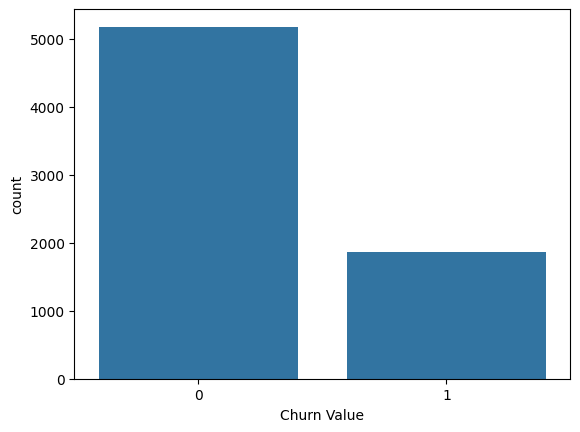

In [21]:
# Count plot
sns.countplot(data=df, x="Churn Value")
plt.show()

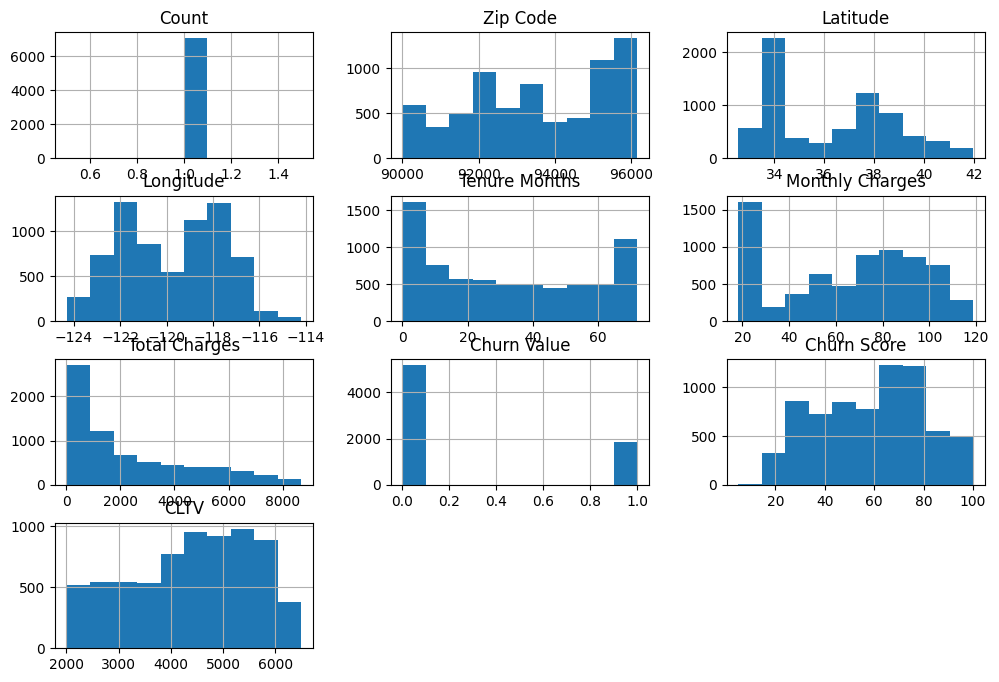

In [22]:
df.hist(figsize=(12,8))
plt.show()

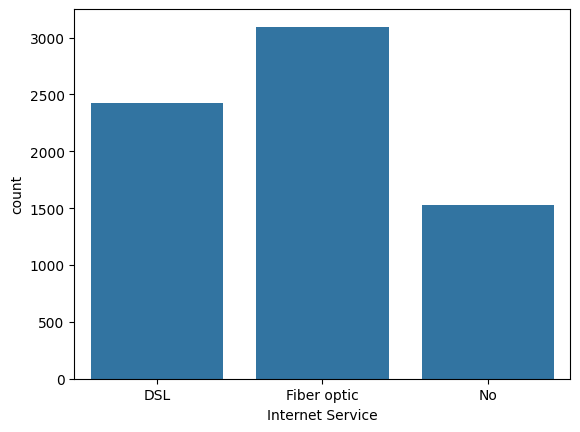

In [23]:
# Categorical Feature Distribution
sns.countplot(data=df, x="Internet Service")
plt.show()

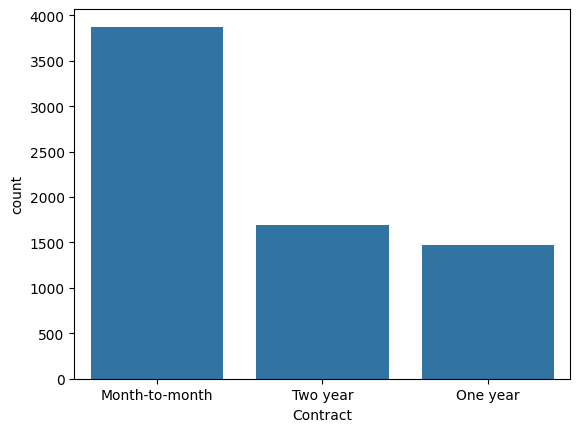

In [24]:
sns.countplot(data=df, x="Contract")
plt.show()

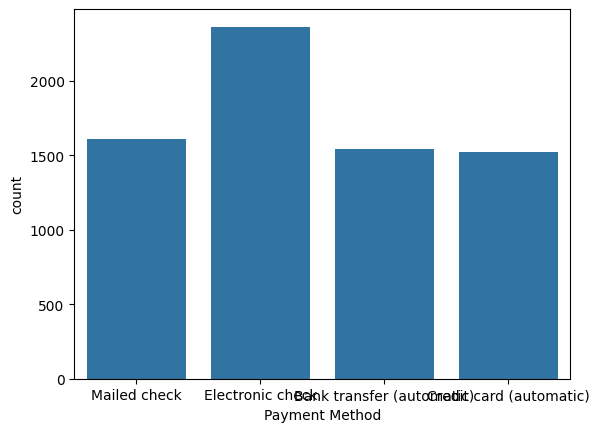

In [25]:
sns.countplot(data=df, x="Payment Method")
plt.show()

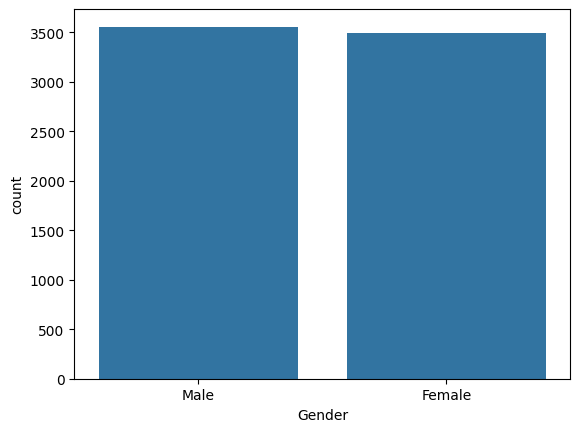

In [26]:
sns.countplot(data=df, x="Gender")
plt.show()

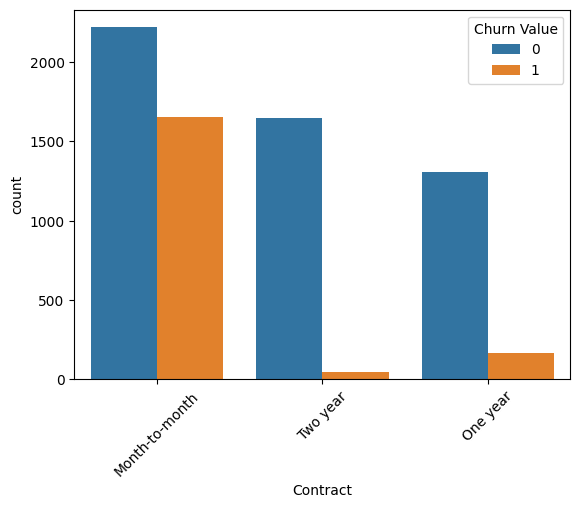

In [27]:
#Relationship with Target
sns.countplot(data=df, x="Contract", hue="Churn Value")
plt.xticks(rotation=45)
plt.show()

**NOTE: Employees with month-to-month contract tends to have higher churn count**

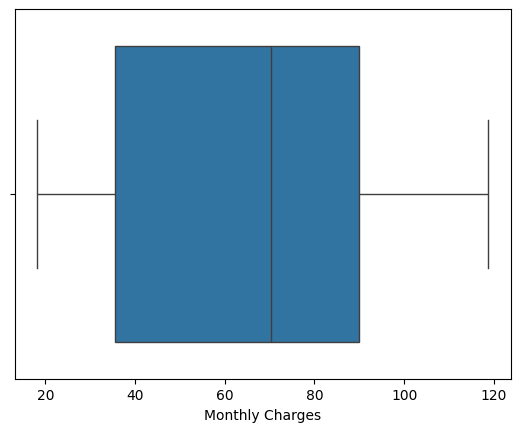

In [28]:
# Outliers 
sns.boxplot(x=df["Monthly Charges"])
plt.show()

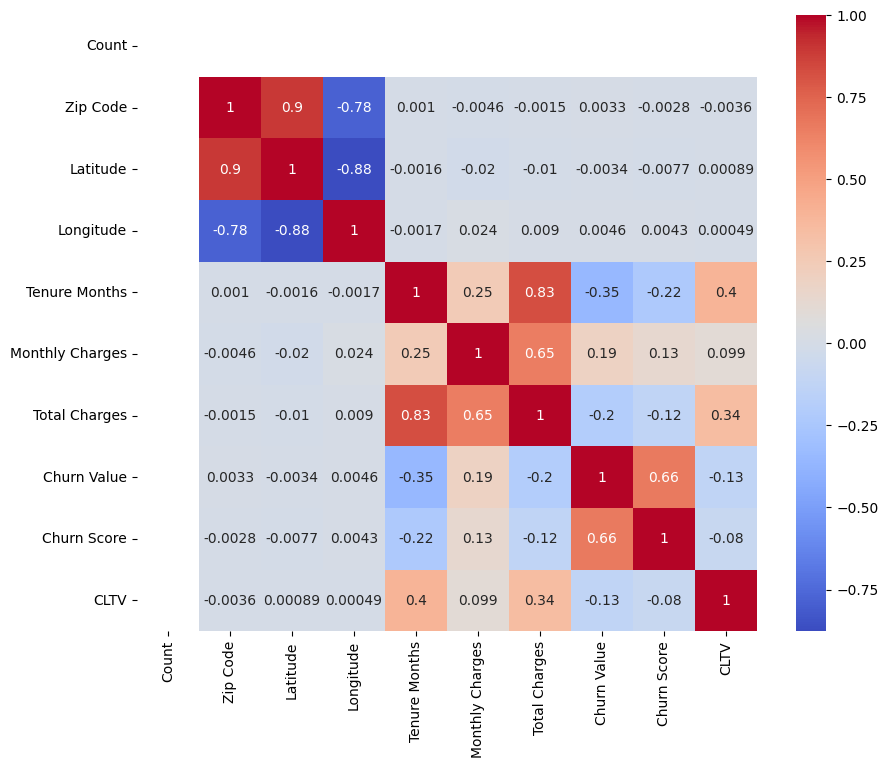

In [29]:
# Correlation Matrix

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.show()

**Summary of Findings**

* Dataset contains 7,043 rows and 21 columns.
* No significant missing values.
* TotalCharges required type conversion.
* Churn is moderately imbalanced.
* Month-to-month contracts have the highest churn.
* Customers with higher tenure are less likely to churn.
* Fiber optic users churn more frequently than DSL users.Electronic check users exhibit higher churn rates.


**Data Cleaning**

In [30]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges          11
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [31]:
# Check the relationship between churn reason and churn value
df.groupby("Churn Value")["Churn Reason"].apply(lambda x: x.isnull().sum())

Churn Value
0    5174
1       0
Name: Churn Reason, dtype: int64

In [32]:
pd.crosstab(df["Churn Value"], df["Churn Reason"].isnull())

Churn Reason,False,True
Churn Value,,
0,0,5174
1,1869,0


In [33]:
#Churn Reason is not a feature you should use to predict churn.
df.drop(columns=["Churn Reason"], inplace=True)

In [34]:
df.dropna(inplace=True)

In [35]:
df.drop("CustomerID", axis=1, inplace=True)

In [36]:
df["Churn Value"].dtype

dtype('int64')

In [37]:
df.select_dtypes(include="object").columns

Index(['Country', 'State', 'City', 'Lat Long', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Phone Service', 'Multiple Lines',
       'Internet Service', 'Online Security', 'Online Backup',
       'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies',
       'Contract', 'Paperless Billing', 'Payment Method', 'Churn Label'],
      dtype='object')

In [38]:
df["Churn Label"] = df["Churn Label"].map({"No": 0, "Yes": 1})

In [39]:
df["Churn Label"].dtype

dtype('int64')

In [40]:
# One hot encoding to convert categorical data to numerical data
df = pd.get_dummies(df, drop_first=False, dtype=int)

In [41]:
print(df.columns)

Index(['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score',
       ...
       'Streaming Movies_Yes', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'Paperless Billing_No', 'Paperless Billing_Yes',
       'Payment Method_Bank transfer (automatic)',
       'Payment Method_Credit card (automatic)',
       'Payment Method_Electronic check', 'Payment Method_Mailed check'],
      dtype='object', length=2837)


In [42]:
df.dtypes

Count                                         int64
Zip Code                                      int64
Latitude                                    float64
Longitude                                   float64
Tenure Months                                 int64
                                             ...   
Paperless Billing_Yes                         int64
Payment Method_Bank transfer (automatic)      int64
Payment Method_Credit card (automatic)        int64
Payment Method_Electronic check               int64
Payment Method_Mailed check                   int64
Length: 2837, dtype: object

In [43]:
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

In [44]:
df.dtypes

Count                                         int64
Zip Code                                      int64
Latitude                                    float64
Longitude                                   float64
Tenure Months                                 int64
                                             ...   
Paperless Billing_Yes                         int64
Payment Method_Bank transfer (automatic)      int64
Payment Method_Credit card (automatic)        int64
Payment Method_Electronic check               int64
Payment Method_Mailed check                   int64
Length: 2837, dtype: object

In [45]:
# Splitting features and target

X = df.drop(["Churn Label", "Churn Value"], axis=1) # Input dataset(only features) shouldn't contain the output
y = df["Churn Value"] # Target

**Train/test split**

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [47]:
# Scaling numerical data to make them unitless
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Training the model**

In [48]:
#Baseline Model 
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [49]:
y_pred = model.predict(X_test)

**Model Evalutation**

In [50]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy \n", accuracy_score(y_test, y_pred))
print("Classification Report \n ", classification_report(y_test, y_pred))
print("Confusion Matrix \n", confusion_matrix(y_test, y_pred))

Accuracy 
 0.8827292110874201
Classification Report 
                precision    recall  f1-score   support

           0       0.92      0.92      0.92      1033
           1       0.78      0.78      0.78       374

    accuracy                           0.88      1407
   macro avg       0.85      0.85      0.85      1407
weighted avg       0.88      0.88      0.88      1407

Confusion Matrix 
 [[949  84]
 [ 81 293]]


**Interpretation:**

* 88 out of every 100 customers
* predictionPrecision = 0.78 When the model predicts a customer will churn, it is correct 78% of the time.
* Recall = 0.78 The model identifies 78% of all customers who actually churn.
* F1-score = 0.78 This balances precision and recall and is a solid score for a baseline model.

